In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams.update({"text.usetex": True, "font.family": "Modern"})

In [17]:
oof_predictions_path = r"C:\Users\user\Repositories\fault-classification-localization\outputs\hv_double_line_90kv/event_type/mlp_classifier\run_20260129_081503\oof_predictions.parquet"

df_oof = pd.read_parquet(oof_predictions_path)

print("Available columns in OOF predictions dataframe: %s" % df_oof.columns.tolist())

display(df_oof)

Available columns in OOF predictions dataframe: ['sample_id', 'event_type', 'fault_class', 'status', 'y_fault_line', 'y_fault_location', 'fold', 'y_true', 'y_pred']


,sample_id,event_type,fault_class,status,y_fault_line,y_fault_location,fold,y_true,y_pred
0,1,flt_2phg_shc,0,clean,Line_2_3_a,87.564949,1,0,0
1,1,flt_2phg_shc,0,clean,Line_2_3_a,87.564949,1,0,0
2,1,flt_2phg_shc,0,clean,Line_2_3_a,87.564949,1,0,0
3,1,flt_2phg_shc,0,clean,Line_2_3_a,87.564949,1,0,0
4,1,flt_2phg_shc,0,clean,Line_2_3_a,87.564949,1,0,0
...,...,...,...,...,...,...,...,...,...
261633,9145,flt_2phg_shc,0,in_fault,Line_2_3_a,88.708923,5,0,0
261634,9145,flt_2phg_shc,0,in_fault,Line_2_3_a,88.708923,5,0,0
261635,9145,flt_2phg_shc,0,in_fault,Line_2_3_a,88.708923,5,0,0
261636,9145,flt_2phg_shc,0,in_fault,Line_2_3_a,88.708923,5,0,0


In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score


def clf_by_location_table(
    df_oof: pd.DataFrame,
    *,
    loc_col: str,
    y_true_col: str = "y_true",
    y_pred_col: str = "y_pred",
    bin_width: int = 10,
    average: str = "macro",
) -> pd.DataFrame:
    """
    Classification performance conditioned on fault location bins.
    Returns: per-bin n, accuracy, precision/recall/f1 (macro by default), error_rate.
    """
    required = {loc_col, y_true_col, y_pred_col}
    missing = required - set(df_oof.columns)
    if missing:
        raise ValueError(f"Missing required cols: {sorted(missing)}")

    df = df_oof.copy()

    # location bins
    bins = list(np.arange(0.0, 100.0 + bin_width, bin_width))
    df["dist_bin"] = pd.cut(
        df[loc_col].astype(float),
        bins=bins,
        right=False,
        include_lowest=True,
    )

    def _safe_metric(fn, yt, yp):
        # Handles bins where only one class appears
        try:
            return float(fn(yt, yp))
        except Exception:
            return np.nan

    rows = []
    for dist_bin, g in df.groupby("dist_bin", observed=True):
        yt = g[y_true_col].to_numpy()
        yp = g[y_pred_col].to_numpy()

        acc = float(np.mean(yt == yp))
        err_rate = 1.0 - acc

        prec = _safe_metric(
            lambda a, b: precision_score(a, b, average=average, zero_division=0), yt, yp
        )
        rec = _safe_metric(
            lambda a, b: recall_score(a, b, average=average, zero_division=0), yt, yp
        )
        f1 = _safe_metric(
            lambda a, b: f1_score(a, b, average=average, zero_division=0), yt, yp
        )

        rows.append(
            {
                "dist_bin": dist_bin,
                "n": int(len(g)),
                "acc": acc,
                "error_rate": err_rate,
                "precision": prec,
                "recall": rec,
                "f1": f1,
            }
        )

    table = pd.DataFrame(rows)

    # nice rounding
    for c in ["acc", "error_rate", "precision", "recall", "f1"]:
        table[c] = table[c].round(3)

    return table

In [19]:
# pick the right location column (example guesses)
print(df_oof.columns)

# e.g. if your parquet has "fault_location_pct"
table_cls = clf_by_location_table(
    df_oof, loc_col="y_fault_location", bin_width=10, average="macro"
)
print(table_cls)

Index(['sample_id', 'event_type', 'fault_class', 'status', 'y_fault_line',
       'y_fault_location', 'fold', 'y_true', 'y_pred'],
      dtype='object')
        dist_bin      n    acc  error_rate  precision  recall     f1
0    [0.0, 10.0)  27260  0.999       0.001      0.995   0.995  0.995
1   [10.0, 20.0)  26419  0.999       0.001      0.991   0.990  0.991
2   [20.0, 30.0)  26158  0.999       0.001      0.991   0.989  0.990
3   [30.0, 40.0)  25114  0.999       0.001      0.995   0.994  0.994
4   [40.0, 50.0)  26709  0.999       0.001      0.995   0.994  0.994
5   [50.0, 60.0)  25781  0.999       0.001      0.992   0.993  0.992
6   [60.0, 70.0)  26303  0.999       0.001      0.996   0.995  0.995
7   [70.0, 80.0)  26187  0.999       0.001      0.992   0.990  0.991
8   [80.0, 90.0)  26419  0.999       0.001      0.993   0.991  0.992
9  [90.0, 100.0)  25288  0.999       0.001      0.995   0.991  0.993


In [13]:
def clf_error_concentration_by_location(
    df_oof: pd.DataFrame,
    *,
    loc_col: str,
    y_true_col: str = "y_true",
    y_pred_col: str = "y_pred",
    bin_width: int = 10,
) -> pd.DataFrame:
    """
    Per location bin:
    - n_total
    - n_err
    - err_rate
    - share_of_all_errors (where do the mistakes happen?)
    """
    df = df_oof.copy()
    df["is_error"] = df[y_true_col] != df[y_pred_col]

    bins = list(np.arange(0.0, 100.0 + bin_width, bin_width))
    df["dist_bin"] = pd.cut(
        df[loc_col].astype(float),
        bins=bins,
        right=False,
        include_lowest=True,
    )

    total_errors = int(df["is_error"].sum())

    out = (
        df.groupby("dist_bin", observed=True)
        .agg(
            n_total=("is_error", "size"),
            n_err=("is_error", "sum"),
        )
        .reset_index()
    )
    out["err_rate"] = out["n_err"] / out["n_total"]
    out["share_of_all_errors"] = (
        (out["n_err"] / total_errors) if total_errors > 0 else 0.0
    )

    out[["err_rate", "share_of_all_errors"]] = out[
        ["err_rate", "share_of_all_errors"]
    ].round(3)
    return out

In [14]:
err_loc = clf_error_concentration_by_location(
    df_oof, loc_col="y_fault_location", bin_width=10
)
print(err_loc)

        dist_bin  n_total  n_err  err_rate  share_of_all_errors
0    [0.0, 10.0)    21620     74     0.003                0.071
1   [10.0, 20.0)    20953    105     0.005                0.100
2   [20.0, 30.0)    20746    107     0.005                0.102
3   [30.0, 40.0)    19918    112     0.006                0.107
4   [40.0, 50.0)    21183     95     0.004                0.091
5   [50.0, 60.0)    20447    122     0.006                0.116
6   [60.0, 70.0)    20861    104     0.005                0.099
7   [70.0, 80.0)    20769    115     0.006                0.110
8   [80.0, 90.0)    20953    118     0.006                0.112
9  [90.0, 100.0)    20056     97     0.005                0.092


In [15]:
import matplotlib.pyplot as plt
import numpy as np


def plot_metric_by_location(
    table: pd.DataFrame, metric: str, *, figsize=(10, 5), bin_width=10
):
    centers = np.array(
        [iv.left + (iv.right - iv.left) / 2 for iv in table["dist_bin"]], dtype=float
    )

    plt.figure(figsize=figsize)
    plt.plot(centers, table[metric].to_numpy(dtype=float), marker="o", linewidth=2)
    plt.xlabel(f"True fault location [\\%] ({bin_width}\\% bins)")
    plt.ylabel(metric)
    plt.grid(True)
    plt.tight_layout()

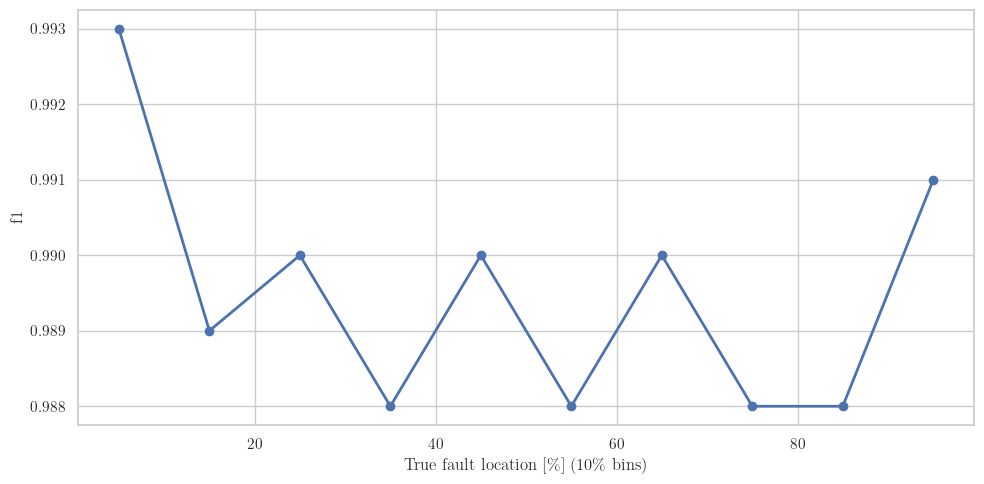

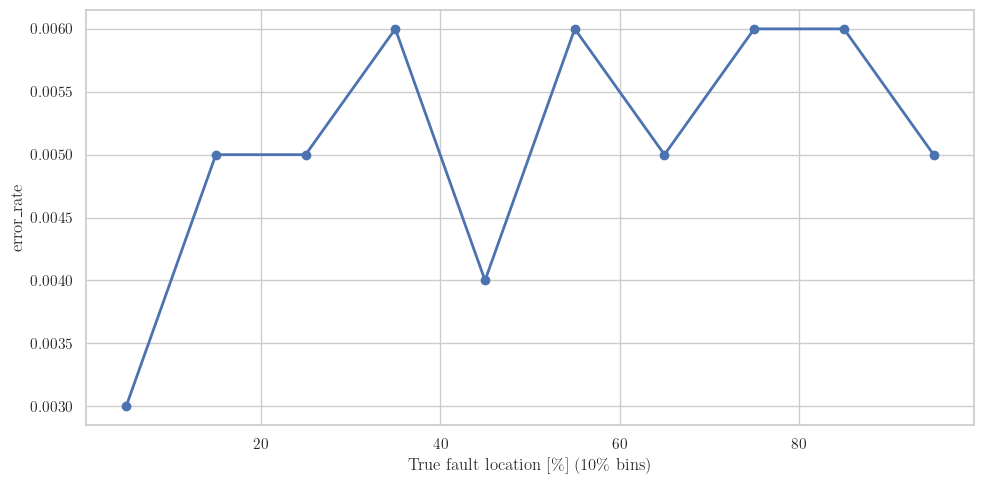

In [16]:
plot_metric_by_location(table_cls, metric="f1", bin_width=10)
plt.show()

plot_metric_by_location(table_cls, metric="error_rate", bin_width=10)
plt.show()